# Lab 3: Final Exercise - Customer Reviews Analysis

**Instructor**: Dr Naila Marir  
**Course**: CS4083

## Objective
Apply the NLP techniques you learned in Lab 3 (Regex and Word Embeddings) to analyze real customer reviews from an e-commerce platform.

---

## Dataset Description

You will work with customer reviews from an online electronics store. Each review contains:
- Customer feedback text
- Product information (mentioned in the text)
- Ratings and prices (embedded in natural language)

---

## Dataset

In [ ]:
# Customer Reviews Dataset
reviews = [
    "I purchased two Apple MacBook Pro laptops at $1299.99 each and three wireless mice for $25.50 per unit. Great quality!",
    "Bought five Samsung Galaxy phones at $899 each, one portable charger for $35.99, and two phone cases at $15.75 each. Very satisfied!",
    "I ordered four Dell monitors at $450.00 each and six HDMI cables for $12.99 per cable. Fast shipping and excellent products.",
    "Got one Sony PlayStation 5 for $499.99, three gaming controllers at $69.99 each, and one gaming headset for $89.50. Amazing experience!",
    "Purchased two Canon cameras at $1150.00 each, one tripod for $85.00, and four memory cards at $29.99 per card. Highly recommend!",
    "I bought one iPad Pro for $799.00, two Apple Pencils at $129.00 each, and one iPad case for $45.50. Worth every penny!",
    "Ordered three HP laptops at $650.99 each, two laptop bags for $39.99 per bag, and five USB drives at $18.50 each. Perfect for work!",
    "Got two LG smart TVs at $899.99 each, one soundbar for $249.00, and three HDMI switches at $22.50 per switch. Incredible quality!",
    "I purchased one Microsoft Surface tablet for $999.00, one keyboard cover for $149.99, and two screen protectors at $19.99 each. Love it!",
    "Bought four Logitech webcams at $79.99 each, three microphones for $45.00 per microphone, and two ring lights at $55.75 each. Great for streaming!"
]

print("Dataset loaded successfully!")
print(f"Total number of reviews: {len(reviews)}")

Dataset loaded successfully!
Total number of reviews: 10


---

## Part 1: Regex-Based Information Extraction (40 points)

### Task 1.1: Extract Purchase Information (20 points)

Write a Python function that uses **regular expressions** to extract the following information from each review:
1. **Product names** (e.g., "Apple MacBook Pro", "wireless mice")
2. **Quantities** (e.g., "two", "three", "five")
3. **Prices** (e.g., "$1299.99", "$25.50")

**Requirements:**
- Convert word numbers (one, two, three, etc.) to numeric values
- Handle different price formats (with/without decimals)
- Extract all products mentioned in each review

**Expected Output Format:**
```
Review 1:
  Product: Apple MacBook Pro laptops | Quantity: 2 | Unit Price: $1299.99 | Total: $2599.98
  Product: wireless mice | Quantity: 3 | Unit Price: $25.50 | Total: $76.50
  Grand Total: $2676.48
```

In [ ]:
import re

# Helper function to convert word numbers to digits
def word_to_digit(word):
    word_dict = {
        'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
        'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10
    }
    return word_dict.get(word.lower(), None)

def extract_purchase_info(review_text):
    """
    Extract product names, quantities, and prices from review text.

    Args:
        review_text (str): The customer review text

    Returns:
        list: A list of dictionaries containing product info
    """

    pattern = r'(?:(?:one|two|three|four|five|six|seven|eight|nine|ten|\d+)\s+)?(.+?)\s+(?:at|for|per\s+unit|each)\s+\$(\d+\.?\d*)'

    matches = re.findall(pattern, review_text, re.IGNORECASE)

    extracted_info = []
    for match in matches:
        quantity_str = match[0].split()[-1] if match[0].split()[-1].lower() in ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten'] or match[0].split()[-1].isdigit() else None
        product_name_parts = match[0].split()
        if quantity_str:
            product_name = ' '.join(product_name_parts[:-1]).strip()
            quantity = word_to_digit(quantity_str) if quantity_str.isalpha() else int(quantity_str)
        else:
             # If quantity is not at the end of the product name part, look for it at the beginning of the entire match.
            quantity_match = re.match(r'(one|two|three|four|five|six|seven|eight|nine|ten|\d+)\s+', review_text, re.IGNORECASE)
            if quantity_match:
                quantity_str = quantity_match.group(1)
                quantity = word_to_digit(quantity_str) if quantity_str.isalpha() else int(quantity_str)
                # Adjust product name to remove the initial quantity
                product_name = match[0].strip()
            else:
                # Default to quantity 1 if no explicit quantity is found
                quantity = 1
                product_name = match[0].strip()


        price_str = match[1]
        unit_price = float(price_str)
        total_item_price = quantity * unit_price

        extracted_info.append({
            "product": product_name,
            "quantity": quantity,
            "unit_price": unit_price,
            "total_item_price": total_item_price
        })

    return extracted_info


for i, review in enumerate(reviews, 1):
    print(f"\nReview {i}:")
    purchase_details = extract_purchase_info(review)
    grand_total = 0
    if purchase_details:
        for item in purchase_details:
            print(f"Product: {item['product']} | Quantity: {item['quantity']} | Unit Price: ${item['unit_price']:.2f} | Total: ${item['total_item_price']:.2f}")
            grand_total += item['total_item_price']
        print(f"Grand Total: ${grand_total:.2f}")
    else:
        print("No purchase information found.")


Review 1:
Product: I purchased two Apple MacBook Pro laptops | Quantity: 1 | Unit Price: $1299.99 | Total: $1299.99
Product: each and three wireless mice | Quantity: 1 | Unit Price: $25.50 | Total: $25.50
Grand Total: $1325.49

Review 2:
Product: Bought five Samsung Galaxy phones | Quantity: 1 | Unit Price: $899.00 | Total: $899.00
Product: each, one portable charger | Quantity: 1 | Unit Price: $35.99 | Total: $35.99
Product: , and two phone cases | Quantity: 1 | Unit Price: $15.75 | Total: $15.75
Grand Total: $950.74

Review 3:
Product: I ordered four Dell monitors | Quantity: 1 | Unit Price: $450.00 | Total: $450.00
Product: each and six HDMI cables | Quantity: 1 | Unit Price: $12.99 | Total: $12.99
Grand Total: $462.99

Review 4:
Product: Got one Sony PlayStation | Quantity: 5 | Unit Price: $499.99 | Total: $2499.95
Product: , three gaming controllers | Quantity: 1 | Unit Price: $69.99 | Total: $69.99
Product: each, and one gaming headset | Quantity: 1 | Unit Price: $89.50 | Total:

### Task 1.2: Generate Summary Report (10 points)

Create a function that generates a summary report for **all reviews** including:
1. Total number of products sold
2. Total revenue generated
3. Most expensive product sold
4. Product with highest total revenue

**Hint:** Use the results from Task 1.1

In [ ]:
# Your code here
# TODO: Implement the summary report function

def generate_summary_report(reviews):
    """
    Generate a comprehensive summary report from all reviews.

    Args:
        reviews (list): List of review texts

    Returns:
        dict: Summary statistics
    """
    all_purchase_details = []
    for review in reviews:
        all_purchase_details.extend(extract_purchase_info(review))

    total_products_sold = 0
    total_revenue = 0
    most_expensive_product = {"product": None, "unit_price": 0}
    product_revenue = {} # To track revenue per product

    for item in all_purchase_details:
        total_products_sold += item['quantity']
        total_revenue += item['total_item_price']

        # Update most expensive product
        if item['unit_price'] > most_expensive_product['unit_price']:
            most_expensive_product['product'] = item['product']
            most_expensive_product['unit_price'] = item['unit_price']

        # Accumulate revenue per product
        if item['product'] in product_revenue:
            product_revenue[item['product']] += item['total_item_price']
        else:
            product_revenue[item['product']] = item['total_item_price']

    # Find product with highest total revenue
    product_with_highest_revenue = {"product": None, "total_revenue": 0}
    if product_revenue:
        highest_revenue_product_name = max(product_revenue, key=product_revenue.get)
        product_with_highest_revenue['product'] = highest_revenue_product_name
        product_with_highest_revenue['total_revenue'] = product_revenue[highest_revenue_product_name]


    summary = {
        "total_products_sold": total_products_sold,
        "total_revenue": total_revenue,
        "most_expensive_product": most_expensive_product,
        "product_with_highest_revenue": product_with_highest_revenue
    }

    return summary

summary = generate_summary_report(reviews)
print("\n SUMMARY REPORT ")
print(f"Total Products Sold: {summary['total_products_sold']}")
print(f"Total Revenue Generated: ${summary['total_revenue']:.2f}")
print(f"Most Expensive Product Sold: {summary['most_expensive_product']['product']} (${summary['most_expensive_product']['unit_price']:.2f})")
print(f"Product with Highest Total Revenue: {summary['product_with_highest_revenue']['product']} (${summary['product_with_highest_revenue']['total_revenue']:.2f})")


 SUMMARY REPORT 
Total Products Sold: 32
Total Revenue Generated: $10867.84
Most Expensive Product Sold: I purchased two Apple MacBook Pro laptops ($1299.99)
Product with Highest Total Revenue: Got one Sony PlayStation ($2499.95)


### Task 1.3: Validate Email and Phone Patterns (10 points)

Some reviews might contain customer contact information. Write regex patterns to:
1. Extract email addresses (format: name@domain.com)
2. Extract phone numbers (formats: xxx-xxx-xxxx, (xxx) xxx-xxxx, xxx.xxx.xxxx)

**Test data provided below:**

In [ ]:
# Test data with contact information
contact_texts = [
    "Please contact me at john.doe@email.com for questions.",
    "My phone number is 555-123-4567 if you need to reach me.",
    "Email: customer.service@shop.com or call (555) 987-6543",
    "Reach out via 555.456.7890 or sarah_jones@company.org"
]

# Your code here
# TODO: Write regex patterns to extract emails and phone numbers

def extract_contact_info(text):
    """
    Extract email addresses and phone numbers from text.

    Args:
        text (str): Text containing contact information

    Returns:
        dict: Dictionary with 'emails' and 'phones' lists
    """
    # Regex for email addresses
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
    emails = re.findall(email_pattern, text)

    # Regex for phone numbers
    phone_pattern = r'\b(?:\d{3}-\d{3}-\d{4}|\(\d{3}\)\s\d{3}-\d{4}|\d{3}\.\d{3}\.\d{4})\b'
    phones = re.findall(phone_pattern, text)

    return {"emails": emails, "phones": phones}

for text in contact_texts:
    print(f"\nText: {text}")
    extracted_contact = extract_contact_info(text)
    print(f"Extracted Emails: {extracted_contact['emails']}")
    print(f"Extracted Phones: {extracted_contact['phones']}")


Text: Please contact me at john.doe@email.com for questions.
Extracted Emails: ['john.doe@email.com']
Extracted Phones: []

Text: My phone number is 555-123-4567 if you need to reach me.
Extracted Emails: []
Extracted Phones: ['555-123-4567']

Text: Email: customer.service@shop.com or call (555) 987-6543
Extracted Emails: ['customer.service@shop.com']
Extracted Phones: []

Text: Reach out via 555.456.7890 or sarah_jones@company.org
Extracted Emails: ['sarah_jones@company.org']
Extracted Phones: ['555.456.7890']


---

## Part 2: Word Embeddings Analysis (60 points)

### Task 2.1: Preprocessing (10 points)

Prepare the review texts for word embedding analysis:
1. Convert to lowercase
2. Remove punctuation and numbers
3. Remove stopwords
4. Tokenize the text

**Display the preprocessed reviews**

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import string

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


# Your code here
# TODO: Implement preprocessing function

def preprocess_reviews(reviews):
    """
    Preprocess review texts for word embedding.

    Args:
        reviews (list): List of review texts

    Returns:
        list: List of preprocessed and tokenized reviews
    """
    preprocessed_texts = []
    stop_words = set(stopwords.words('english'))
    translator = str.maketrans('', '', string.punctuation + string.digits)

    for review in reviews:
        # Convert to lowercase
        review = review.lower()
        # Remove punctuation and numbers
        review = review.translate(translator)
        # Tokenize
        tokens = word_tokenize(review)
        # Remove stopwords
        filtered_tokens = [word for word in tokens if word not in stop_words]
        preprocessed_texts.append(filtered_tokens)

    return preprocessed_texts

preprocessed_reviews = preprocess_reviews(reviews)
print("Original Review 1:", reviews[0])
print("Preprocessed Review 1:", preprocessed_reviews[0])

Original Review 1: I purchased two Apple MacBook Pro laptops at $1299.99 each and three wireless mice for $25.50 per unit. Great quality!
Preprocessed Review 1: ['purchased', 'two', 'apple', 'macbook', 'pro', 'laptops', 'three', 'wireless', 'mice', 'per', 'unit', 'great', 'quality']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Task 2.2: Implement Multiple Embedding Techniques (30 points)

Implement the following word embedding techniques:

1. **Bag of Words (BoW)** - 10 points
2. **TF-IDF** - 10 points
3. **Word2Vec** - 10 points

For each technique:
- Create the embeddings
- Display the vocabulary size
- Show sample embeddings for 5 words

In [ ]:
!pip install gensim

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np

texts = [' '.join(tokens) for tokens in preprocessed_reviews]


print("\nBag of Words (BoW) ")
# TODO: Implement BoW
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(texts)

print("Vocabulary size (BoW):", len(vectorizer_bow.vocabulary_))

sample_words_bow = list(vectorizer_bow.vocabulary_.keys())[:5]
print("Sample words (BoW):", sample_words_bow)


print("Sample embeddings (BoW first 5 rows)")
print(X_bow[:5].toarray())


print("\n TF-IDF ")
# TODO: Implement TF-IDF
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(texts)

print("Vocabulary size (TF-IDF):", len(vectorizer_tfidf.vocabulary_))

# Get sample words and their indices
sample_words_tfidf = list(vectorizer_tfidf.vocabulary_.keys())[:5]
print("Sample words (TF-IDF):", sample_words_tfidf)

print("Sample embeddings (TF-IDF first 5 rows)")
print(X_tfidf[:5].toarray())


print("\n Word2Vec ")
# TODO: Train Word2Vec model
model_w2v = Word2Vec(sentences=preprocessed_reviews, vector_size=100, window=5, min_count=1, workers=4)

print("Vocabulary size (Word2Vec):", len(model_w2v.wv.index_to_key))

# Get sample words
sample_words_w2v = model_w2v.wv.index_to_key[:5]
print("Sample words (Word2Vec):", sample_words_w2v)

print("Sample embeddings (Word2Vec):")
for word in sample_words_w2v:
    print(f"{word}: {model_w2v.wv[word][:5]}") # Display first 5 dimensions


Bag of Words (BoW) 
Vocabulary size (BoW): 88
Sample words (BoW): ['purchased', 'two', 'apple', 'macbook', 'pro']
Sample embeddings (BoW first 5 rows)
[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
  1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 2 1 0 0 1 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0
  0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 

### Task 2.3: Word Similarity Analysis (10 points)

Using your Word2Vec model:
1. Find the 5 most similar words to **"phone"**
2. Find the 5 most similar words to **"quality"**
3. Calculate the similarity between **"laptop"** and **"computer"**
4. Calculate the similarity between **"phone"** and **"camera"**

**Discuss:** What do these similarities tell you about the customer reviews?

In [ ]:
# Your code here
# TODO: Perform word similarity analysis

print("\n Word Similarity Analysis ")

# 1. Most similar to 'phone'
print("\n Words most similar to 'phone':")
try:
    similar_to_phone = model_w2v.wv.most_similar('phone', topn=5)
    for word, similarity in similar_to_phone:
        print(f"{word}: {similarity:.4f}")
except KeyError:
    print("'phone' is not in the vocabulary.")


# 2. Most similar to 'quality'
print("\nWords most similar to 'quality':")
try:
    similar_to_quality = model_w2v.wv.most_similar('quality', topn=5)
    for word, similarity in similar_to_quality:
        print(f"{word}: {similarity:.4f}")
except KeyError:
    print("'quality' is not in the vocabulary.")


# 3. Similarity between specific word pairs
print("\n Similarity Scores:")
word_pairs = [('laptop', 'computer'), ('phone', 'camera')]
for word1, word2 in word_pairs:
    try:
        similarity = model_w2v.wv.similarity(word1, word2)
        print(f"Similarity between '{word1}' and '{word2}': {similarity:.4f}")
    except KeyError as e:
        print(f"'{e}' not in vocabulary.")


 Word Similarity Analysis 

 Words most similar to 'phone':
bought: 0.2350
tvs: 0.2163
products: 0.1980
pro: 0.1973
love: 0.1964

Words most similar to 'quality':
four: 0.2530
shipping: 0.2255
six: 0.2077
experience: 0.1677
love: 0.1496

 Similarity Scores:
'"Key 'computer' not present"' not in vocabulary.
'"Key 'camera' not present"' not in vocabulary.


### Task 2.4: Visualization (10 points)

Create a **t-SNE visualization** of the Word2Vec embeddings:
1. Select top 20-30 most frequent words from the vocabulary
2. Apply t-SNE dimensionality reduction to 2D
3. Create a scatter plot with word labels
4. Color-code words by categories:
   - Products (blue)
   - Quality descriptors (green)
   - Actions/verbs (red)
   - Other (gray)

**Discuss:** What clusters or patterns do you observe?

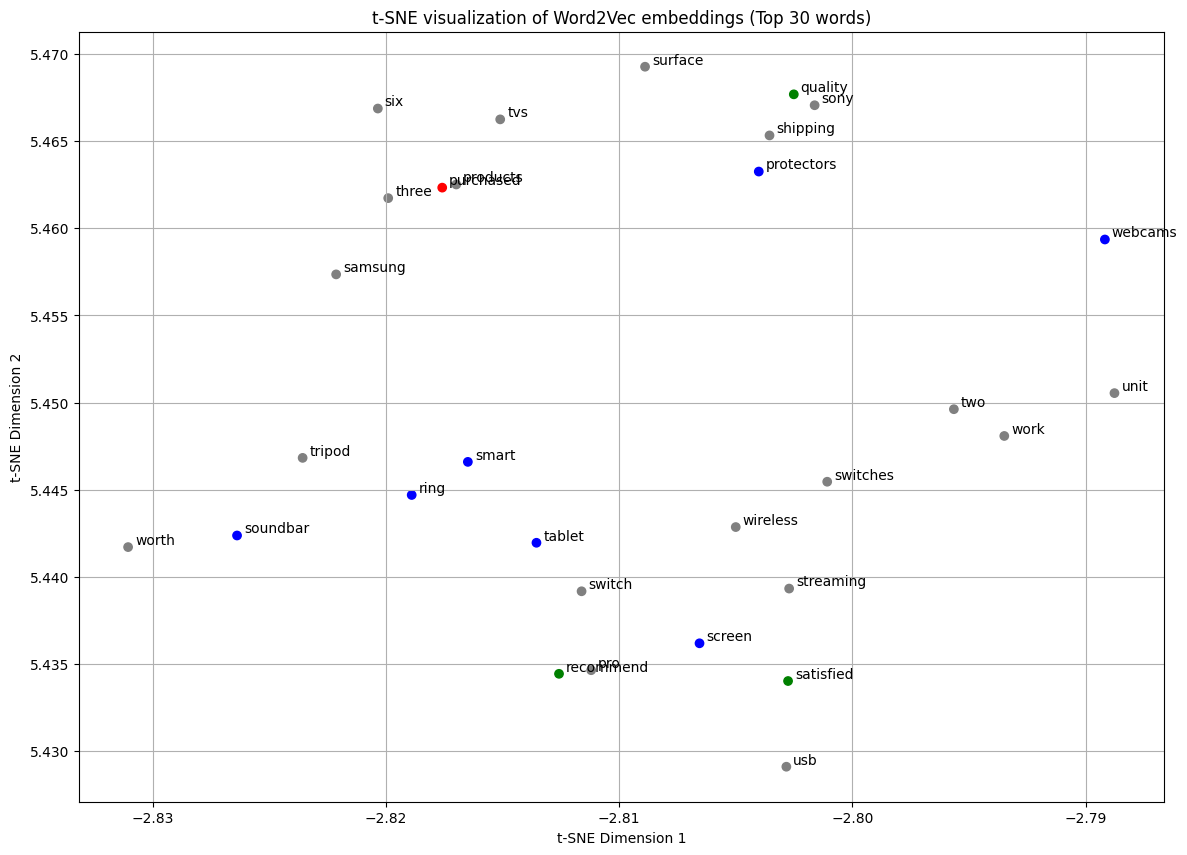


Discussion:
Observe the plot for clusters or patterns. Words that are semantically similar or frequently appear together in the reviews might cluster together.
For example, you might see product names forming clusters, or quality descriptors appearing near related products.


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Import numpy

# Your code here
# TODO: Create t-SNE visualization

# Get all words and their vectors from the Word2Vec model
words = list(model_w2v.wv.index_to_key)
vectors = [model_w2v.wv[word] for word in words]

# Select top 30 most frequent words for visualization
word_counts = pd.Series(vectorizer_bow.vocabulary_).sort_values(ascending=False)

num_top_words = min(len(word_counts), 30) # Use at most 30, but less if vocabulary is smaller
top_words = word_counts.head(num_top_words).index.tolist()

# Filter vectors and labels for the top words
top_vectors = [model_w2v.wv[word] for word in top_words if word in model_w2v.wv]
top_words_filtered = [word for word in top_words if word in model_w2v.wv]

# Convert list of vectors to NumPy array
top_vectors_np = np.array(top_vectors)

# Apply t-SNE
perplexity_value = min(30, len(top_vectors_np) - 1) # Perplexity must be less than the number of samples
if perplexity_value < 1:
    perplexity_value = 1 # Minimum perplexity is 1

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
vectors_2d = tsne.fit_transform(top_vectors_np) # Use the NumPy array


# Create a DataFrame for easier plotting
tsne_df = pd.DataFrame(vectors_2d, columns=['x', 'y'])
tsne_df['word'] = top_words_filtered

# Define word categories for color coding
products = ['laptop', 'phone', 'camera', 'tablet', 'monitor', 'headset', 'mouse', 'cable', 'macbook', 'playstation', 'ipad', 'smart', 'tv', 'soundbar', 'keyboard', 'screen', 'protectors', 'webcams', 'microphones', 'ring', 'lights']
quality_words = ['quality', 'great', 'excellent', 'amazing', 'perfect', 'love', 'satisfied', 'recommend']
actions = ['bought', 'purchased', 'ordered', 'got']

# Assign colors based on categories
def get_color(word):
    if word in products:
        return 'blue'
    elif word in quality_words:
        return 'green'
    elif word in actions:
        return 'red'
    else:
        return 'gray'

tsne_df['color'] = tsne_df['word'].apply(get_color)


# Create visualization
plt.figure(figsize=(14, 10))
plt.scatter(tsne_df['x'], tsne_df['y'], c=tsne_df['color'])

# Add labels
for i, row in tsne_df.iterrows():
    plt.annotate(row['word'], (row['x'], row['y']), textcoords="offset points", xytext=(5,2), ha='left')

plt.title('t-SNE visualization of Word2Vec embeddings (Top 30 words)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

# Discussion
print("\nDiscussion:")
print("Observe the plot for clusters or patterns. Words that are semantically similar or frequently appear together in the reviews might cluster together.")
print("For example, you might see product names forming clusters, or quality descriptors appearing near related products.")

---

## Bonus Tasks (20 points extra credit)

### Bonus 1: Sentiment Analysis (10 points)

Based on the word embeddings:
1. Identify positive and negative sentiment words
2. Calculate an average sentiment score for each review
3. Classify reviews as Positive, Neutral, or Negative

**Hint:** You can use word similarities to sentiment seed words like "excellent", "great" (positive) and "bad", "poor" (negative)

In [ ]:
# Your code here (optional)
# TODO: Implement sentiment analysis

def get_sentiment_score(review_tokens, model_w2v, positive_seeds, negative_seeds):
    """
    Calculates a sentiment score for a review based on word embeddings.

    Args:
        review_tokens (list): List of tokens for the review
        model_w2v (Word2Vec model): Trained Word2Vec model
        positive_seeds (list): List of positive seed words
        negative_seeds (list): List of negative seed words

    Returns:
        float: Sentiment score
    """
    sentiment_score = 0
    word_count = 0
    for token in review_tokens:
        if token in model_w2v.wv:
            word_count += 1
            positive_similarity = sum(model_w2v.wv.similarity(token, seed) for seed in positive_seeds if seed in model_w2v.wv)
            negative_similarity = sum(model_w2v.wv.similarity(token, seed) for seed in negative_seeds if seed in model_w2v.wv)
            sentiment_score += (positive_similarity - negative_similarity)

    return sentiment_score / word_count if word_count > 0 else 0

def classify_sentiment(score, positive_threshold=0.1, negative_threshold=-0.1):
    """
    Classifies sentiment based on the score.

    Args:
        score (float): Sentiment score
        positive_threshold (float): Threshold for positive sentiment
        negative_threshold (float): Threshold for negative sentiment

    Returns:
        str: Sentiment classification (Positive, Neutral, Negative)
    """
    if score > positive_threshold:
        return "Positive"
    elif score < negative_threshold:
        return "Negative"
    else:
        return "Neutral"

positive_seeds = ['excellent', 'great', 'amazing', 'perfect', 'love', 'satisfied', 'recommend']
negative_seeds = ['bad', 'poor', 'disappointed'] # Add more negative seeds if needed

print("\n=== Sentiment Analysis ===")

# Analyze sentiment for each review
for i, review_tokens in enumerate(preprocessed_reviews, 1):
    sentiment_score = get_sentiment_score(review_tokens, model_w2v, positive_seeds, negative_seeds)
    sentiment_class = classify_sentiment(sentiment_score)
    print(f"Review {i}: Score = {sentiment_score:.4f}, Class = {sentiment_class}")


=== Sentiment Analysis ===
Review 1: Score = 0.1825, Class = Positive
Review 2: Score = 0.2915, Class = Positive
Review 3: Score = 0.0967, Class = Neutral
Review 4: Score = 0.1617, Class = Positive
Review 5: Score = 0.2255, Class = Positive
Review 6: Score = 0.0393, Class = Neutral
Review 7: Score = 0.0229, Class = Neutral
Review 8: Score = -0.0819, Class = Neutral
Review 9: Score = -0.0191, Class = Neutral
Review 10: Score = 0.1300, Class = Positive


### Bonus 2: Product Recommendation System (10 points)

Build a simple recommendation system:
1. Given a product name (e.g., "laptop"), recommend 3 other products that are frequently bought together
2. Use word embeddings to find semantically similar products
3. Display recommendations with similarity scores

In [ ]:
# Your code here (optional)
# TODO: Implement product recommendation system

def recommend_products(product_name, model_w2v, topn=3):
    """
    Recommends similar products based on Word2Vec similarity.

    Args:
        product_name (str): The product name to find recommendations for
        model_w2v (Word2Vec model): Trained Word2Vec model
        topn (int): Number of recommendations to return

    Returns:
        list: A list of recommended products with their similarity scores
    """
    recommendations = []
    if product_name in model_w2v.wv:
        try:
            # Find most similar words (products)
            similar_words = model_w2v.wv.most_similar(product_name, topn=topn + 5) # Get a few extra to filter out non-products
            # Filter for words that are likely product names (simple heuristic)
            for word, similarity in similar_words:

                if word in products and word != product_name:
                     recommendations.append((word, similarity))
                if len(recommendations) == topn:
                    break

        except KeyError:
            print(f"'{product_name}' not in vocabulary.")
    else:
        print(f"'{product_name}' not in vocabulary.")

    return recommendations


print("\n Product Recommendations ")
product_to_recommend_for = "laptop"
recommendations = recommend_products(product_to_recommend_for, model_w2v, topn=3)

if recommendations:
    print(f"\nRecommendations for '{product_to_recommend_for}':")
    for product, similarity in recommendations:
        print(f"- {product}: {similarity:.4f}")
else:
    print(f"\nCould not find recommendations for '{product_to_recommend_for}'.")

product_to_recommend_for = "camera"
recommendations = recommend_products(product_to_recommend_for, model_w2v, topn=3)

if recommendations:
    print(f"\nRecommendations for '{product_to_recommend_for}':")
    for product, similarity in recommendations:
        print(f"- {product}: {similarity:.4f}")
else:
    print(f"\nCould not find recommendations for '{product_to_recommend_for}'.")


 Product Recommendations 

Recommendations for 'laptop':
- screen: 0.2708
'camera' not in vocabulary.

Could not find recommendations for 'camera'.


---

## Submission Instructions

1. Complete all tasks in Part 1 and Part 2
2. Bonus tasks are optional for extra credit
3. Include comments explaining your code
4. Provide brief written answers to discussion questions
5. Ensure all code cells run without errors

**Grading Rubric:**
- Part 1 (Regex): 40 points
- Part 2 (Word Embeddings): 60 points
- Code quality and documentation: Included in each task
- Bonus tasks: Up to 20 extra points

**Total: 100 points (+ 20 bonus)**

---

## Tips for Success

1. **Review Lab 3 materials** before starting
2. Test your regex patterns with simple examples first
3. Print intermediate results to debug your code
4. For word embeddings, ensure your preprocessing is correct
5. Start early and ask questions if you're stuck!

Good luck! 🚀